## Aircraft Surface Defect Detection Using AI

This project investigates the use of Convolutional Neural Networks (CNNs) for automated classification of aircraft surface defects, with the goal of improving inspection accuracy and efficiency.

---
*The model performance is limited by dataset size and class distribution. More balanced and larger datasets would likely improve accuracy*.


In [45]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import kagglehub
import shutil

## Download and Extract Dataset

The dataset needs to be downloaded and extracted into the 'Data' directory.

In [46]:
# Download the dataset using kagglehub
# This will download the dataset to a kagglehub cache directory
kaggle_download_path = kagglehub.dataset_download("fatimaazfarziya/aircraft-defects-image-data")
print(f"KaggleHub dataset downloaded to: {kaggle_download_path}")

# Expected structure from this Kaggle dataset: kaggle_download_path/Data
# We want to copy kaggle_download_path/Data to ./Data
source_data_path = os.path.join(kaggle_download_path, 'Data')
destination_data_path = './Data'

# Check if the source 'Data' directory exists within the downloaded path
if os.path.exists(source_data_path):
    # If the destination 'Data' directory already exists, remove it to avoid conflicts
    if os.path.exists(destination_data_path):
        print(f"Removing existing '{destination_data_path}' directory...")
        shutil.rmtree(destination_data_path)

    # Copy the 'Data' directory to the current working directory
    print(f"Copying '{source_data_path}' to '{destination_data_path}'...")
    shutil.copytree(source_data_path, destination_data_path) # Changed from shutil.move to shutil.copytree
    print("Data directory copied successfully.")
else:
    print(f"Error: '{source_data_path}' not found. Please check the dataset structure.")
    print(f"Contents of {kaggle_download_path}: {os.listdir(kaggle_download_path)}")


# Verify existence of the copied 'Data' directory and its subdirectories
print("Data directory exists after copy:", os.path.exists(destination_data_path))
print("Train path exists:", os.path.exists(os.path.join(destination_data_path, "Train")))
print("Validation path exists:", os.path.exists(os.path.join(destination_data_path, "Valid")))
print("Test path exists:", os.path.exists(os.path.join(destination_data_path, "Test")))

Using Colab cache for faster access to the 'aircraft-defects-image-data' dataset.
KaggleHub dataset downloaded to: /kaggle/input/aircraft-defects-image-data
Removing existing './Data' directory...
Copying '/kaggle/input/aircraft-defects-image-data/Data' to './Data'...
Data directory copied successfully.
Data directory exists after copy: True
Train path exists: True
Validation path exists: True
Test path exists: True


## Dataset Description

The dataset consists of aircraft surface images categorized into six defect classes:

- Corrosion
- Crack
- Dent
- Missing Head
- Paint Off
- Scratch

The dataset is divided into:
- Training set
- Validation set
- Test set

This structure allows the model to be trained, validated, and tested on separate image groups.

In [47]:
train_dir = "Data/Train"
val_dir = "Data/Valid"
test_dir = "Data/Test"

print("Train path exists:", os.path.exists(train_dir))
print("Validation path exists:", os.path.exists(val_dir))
print("Test path exists:", os.path.exists(test_dir))

Train path exists: True
Validation path exists: True
Test path exists: True


## Loading Dataset

Images are loaded directly from folders using TensorFlow.

Each class is represented by a separate folder, so labels are assigned automatically based on directory names.

All images are resized to 224 × 224 pixels and loaded in batches.

In [48]:
img_height = 224
img_width = 224
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 2591 files belonging to 6 classes.
Found 508 files belonging to 6 classes.
Found 154 files belonging to 6 classes.
Classes: ['Corrosion', 'Crack', 'Dent', 'Missing Head', 'Paint Off', 'Scratch']
Number of classes: 6


## Data Preview

Before training, a small sample of images is displayed to verify that the dataset is loaded correctly.

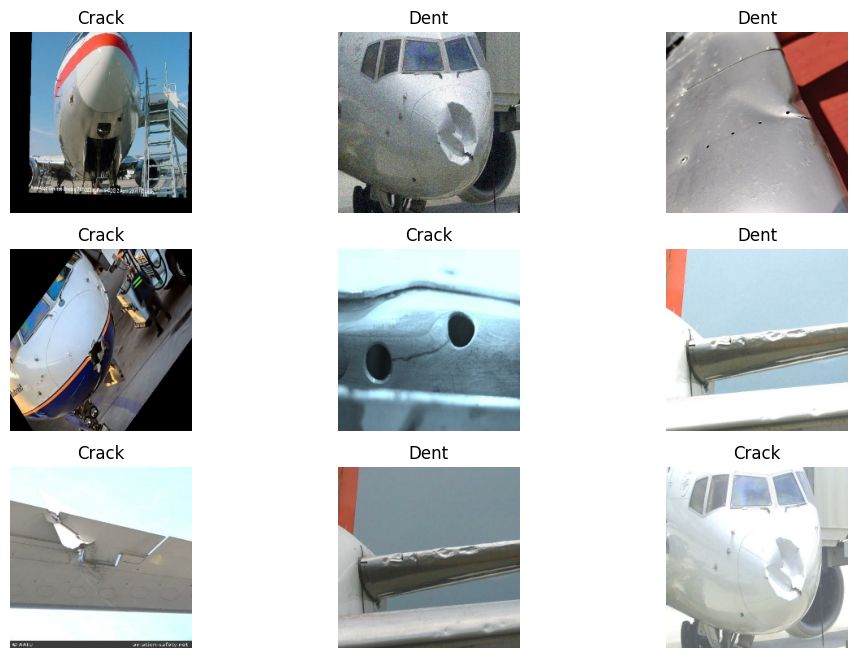

In [49]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Preprocessing and Augmentation

For the initial custom CNN, pixel values are normalized from the range 0–255 to 0–1. For the transfer learning model (MobileNetV2), a specific preprocessing function is applied that scales pixel values to the range [-1, 1].

To improve generalization and reduce overfitting, data augmentation is applied to the training data:
- random horizontal flip
- random rotation
- random zoom

This helps the model learn more robust visual features.

In [50]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

## Model Architecture

A Convolutional Neural Network (CNN) is used for image classification.

The model includes:
- Conv2D layers for extracting visual features such as edges, textures, and defect patterns
- MaxPooling layers for reducing spatial dimensions
- Dense layers for classification
- Dropout regularization to reduce overfitting

CNN was selected because it is highly effective for image recognition tasks.

In [51]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Rescaling(1./255),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compilation

The model is compiled with:
- Adam optimizer
- sparse categorical crossentropy loss
- accuracy as the main evaluation metric

In [52]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training

The model is trained on the training dataset and evaluated on the validation dataset.

In [53]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.4986 - loss: 1.4021 - val_accuracy: 0.3957 - val_loss: 1.4706
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.5627 - loss: 1.1843 - val_accuracy: 0.3957 - val_loss: 1.5052
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.5809 - loss: 1.0852 - val_accuracy: 0.3661 - val_loss: 1.4732
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.6029 - loss: 1.0269 - val_accuracy: 0.3740 - val_loss: 1.6351
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.6094 - loss: 1.0008 - val_accuracy: 0.3799 - val_loss: 1.5875
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.6210 - loss: 0.9545 - val_accuracy: 0.4134 - val_loss: 1.5874
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.6457 - loss: 0.9252 - val_accuracy: 0.4193 - val_loss: 1.6866
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.6314 - loss: 0.9257 - val_accuracy: 0.3957 -

## Initial Results

The training and validation accuracy curves are used to monitor learning behavior and identify possible overfitting.

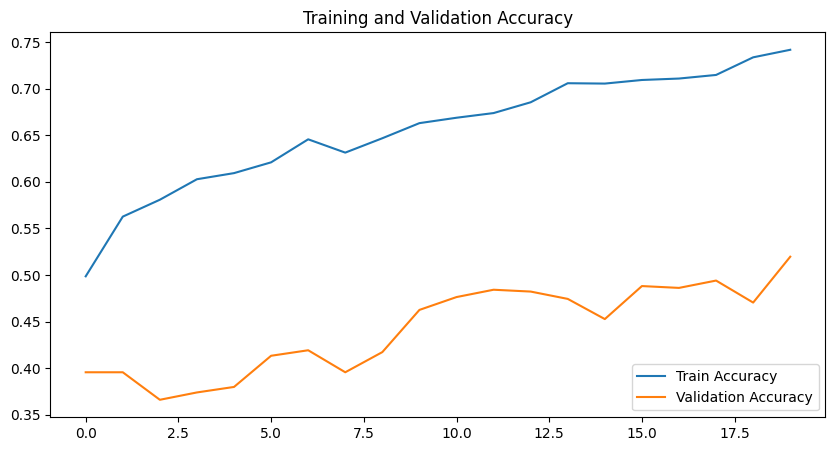

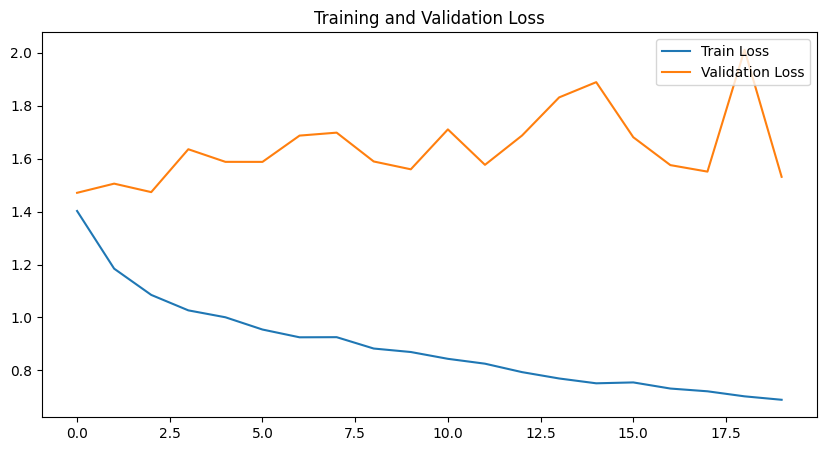

In [54]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [55]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4935 - loss: 1.7115
Test Accuracy: 0.4935064911842346
Test Loss: 1.7114506959915161


## Evaluation
The initial custom CNN achieved a test accuracy of approximately 49.35% with a test loss of 1.71. These results indicated limited generalization to unseen data.

## Sample Predictions

A few sample predictions are displayed below to visually inspect how the model classifies aircraft defect images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


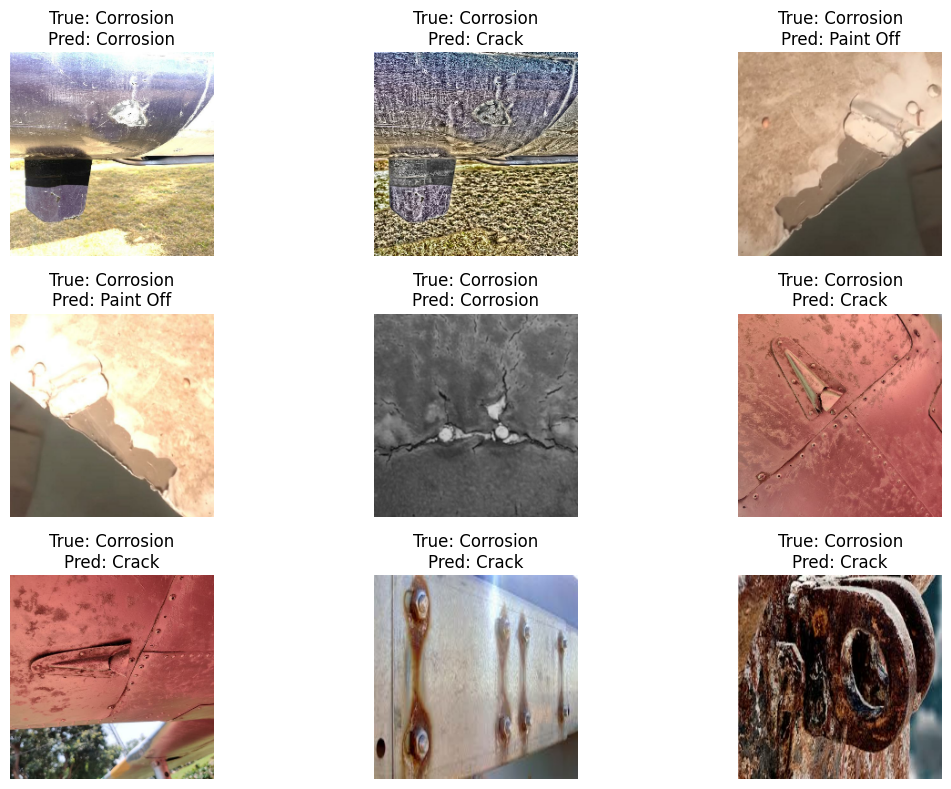

In [56]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = class_names[labels[i]]
        predicted_label = class_names[predicted_classes[i]]
        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

## Improving Accuracy with Transfer Learning

To further improve the model's accuracy, especially given the dataset size, we will implement **transfer learning**. This technique utilizes a pre-trained convolutional neural network (CNN) as a feature extractor, which has already learned to identify complex patterns from a very large dataset. We will use `MobileNetV2` and add our own classification layers on top.

This approach helps with:
- **Faster Training**: The base model's weights are already learned.
- **Better Generalization**: The pre-trained model has seen a vast amount of image data, allowing it to extract more robust features.
- **Overcoming Limited Data**: It reduces the need for a very large dataset for effective training.

In [57]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Create the base model from the pre-trained MobileNetV2 model
# Exclude the top classification layer
base_model = MobileNetV2(input_shape=(img_height, img_width, 3),
                                 include_top=False,
                                 weights='imagenet')

# Freeze the base model to prevent its weights from being updated during training
base_model.trainable = False

# Add custom classification layers on top of the base model
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x) # Add dropout for regularization
predictions = layers.Dense(num_classes, activation='softmax')(x)

# Create the new model
transfer_model = Model(inputs=base_model.input, outputs=predictions)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Compile the Transfer Learning Model

The new `transfer_model` needs to be compiled with an optimizer, loss function, and metrics, similar to the previous model.

In [58]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001), # Use a lower learning rate for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train the Transfer Learning Model

Now, we will train the `transfer_model` for a few epochs. We'll include early stopping again to prevent overfitting and save the best weights. We also need to normalize the pixel values inside the dataset pipeline, instead of in the model, because `MobileNetV2` expects input values in the range [-1, 1], which is handled by its internal preprocessing.

In [59]:
# Preprocessing function for MobileNetV2
def preprocess_image_mobilenet(image, label):
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

# Apply preprocessing to the datasets
train_ds_preprocessed = train_ds.map(preprocess_image_mobilenet).prefetch(buffer_size=AUTOTUNE)
val_ds_preprocessed = val_ds.map(preprocess_image_mobilenet).prefetch(buffer_size=AUTOTUNE)
test_ds_preprocessed = test_ds.map(preprocess_image_mobilenet).prefetch(buffer_size=AUTOTUNE)

# Define Early Stopping callback
early_stop_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, # Increased patience for more stable monitoring
    restore_best_weights=True
)

# Train the transfer learning model
history_transfer = transfer_model.fit(
    train_ds_preprocessed,
    validation_data=val_ds_preprocessed,
    epochs=30, # Start with more epochs, let early stopping manage it
    callbacks=[early_stop_callback]
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 60s 480ms/step - accuracy: 0.4411 - loss: 1.5821 - val_accuracy: 0.4213 - val_loss: 1.3730
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.5990 - loss: 1.0432 - val_accuracy: 0.5079 - val_loss: 1.2122
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.6804 - loss: 0.8724 - val_accuracy: 0.5610 - val_loss: 1.1328
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.7237 - loss: 0.7774 - val_accuracy: 0.6043 - val_loss: 1.0666
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.7638 - loss: 0.6893 - val_accuracy: 0.6260 - val_loss: 1.0437
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.7873 - loss: 0.6121 - val_accuracy: 0.6437 - val_loss: 1.0082
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.8036 - loss: 0.5641 - val_accuracy: 0.6437 - val_loss: 1.0224
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.8244 - loss: 0.5275 - val_accuracy: 0.6496 

## Evaluate Transfer Learning Model

Let's evaluate the performance of the transfer learning model on the test dataset.

In [60]:
test_loss_transfer, test_acc_transfer = transfer_model.evaluate(test_ds_preprocessed)
print("Transfer Model Test Accuracy:", test_acc_transfer)
print("Transfer Model Test Loss:", test_loss_transfer)

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.6688 - loss: 1.1463
Transfer Model Test Accuracy: 0.6688311696052551
Transfer Model Test Loss: 1.1462641954421997


After implementing the transfer learning model (MobileNetV2), the performance improved significantly, reaching a test accuracy of approximately 66.88% and reducing the test loss to 1.15. This confirms that the transfer learning approach is far more effective for this specific defect detection task.

## Visualize Transfer Learning Training History

We will plot the training and validation accuracy and loss for the transfer learning model to observe its learning curve.

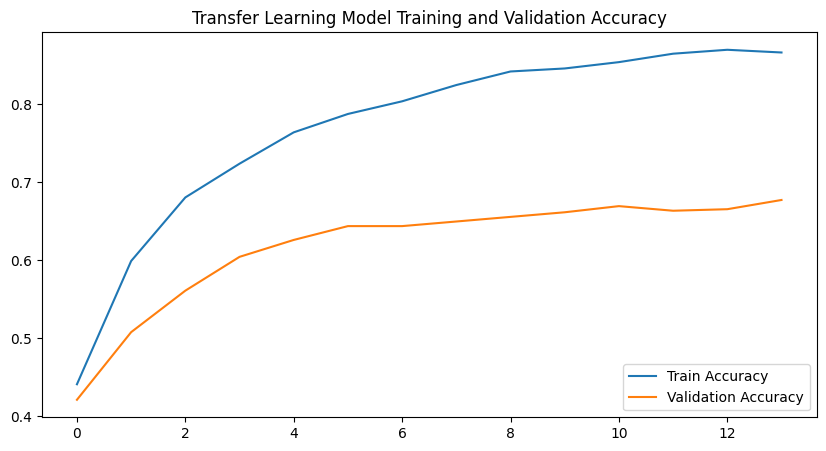

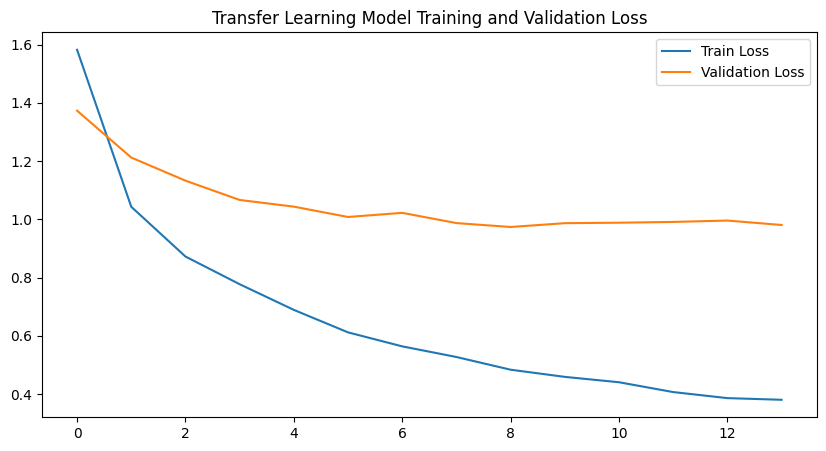

In [61]:
acc_transfer = history_transfer.history['accuracy']
val_acc_transfer = history_transfer.history['val_accuracy']
loss_transfer = history_transfer.history['loss']
val_loss_transfer = history_transfer.history['val_loss']

epochs_range_transfer = range(len(acc_transfer))

plt.figure(figsize=(10, 5))
plt.plot(epochs_range_transfer, acc_transfer, label='Train Accuracy')
plt.plot(epochs_range_transfer, val_acc_transfer, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Transfer Learning Model Training and Validation Accuracy')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_range_transfer, loss_transfer, label='Train Loss')
plt.plot(epochs_range_transfer, val_loss_transfer, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Transfer Learning Model Training and Validation Loss')
plt.show()

## Sample Predictions with Transfer Learning Model

Let's visualize some sample predictions from the new transfer learning model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


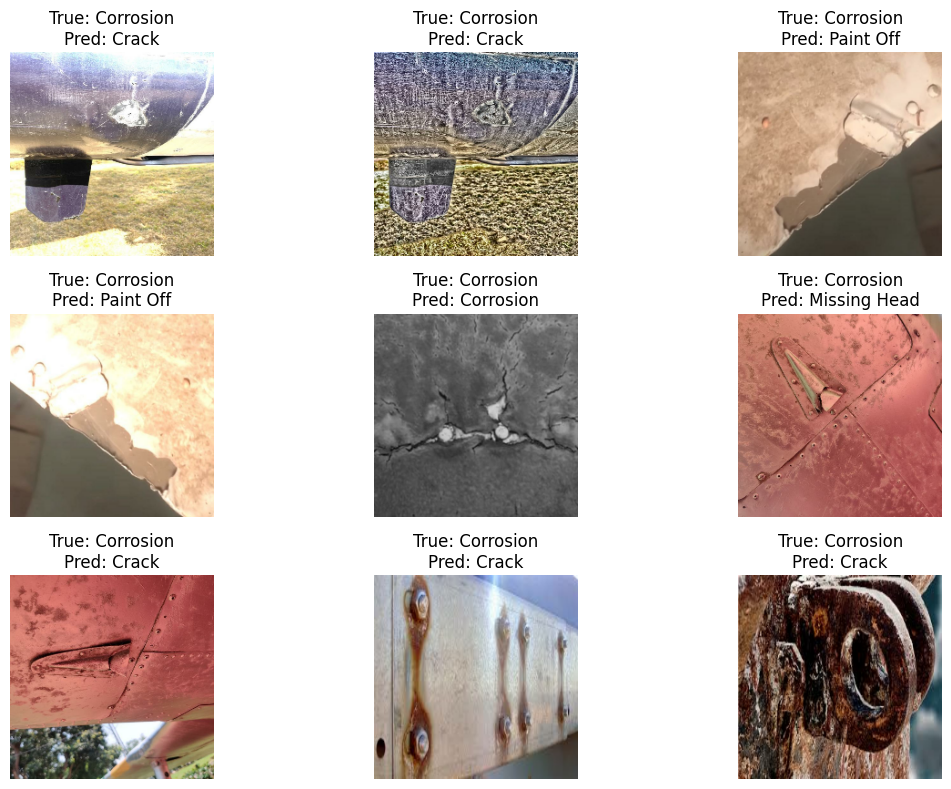

In [63]:
plt.figure(figsize=(12, 8))

# Take one batch from the test dataset
for images, labels in test_ds.take(1):
    # Apply preprocessing once for the entire batch to avoid repeated retracing
    preprocessed_images = tf.keras.applications.mobilenet_v2.preprocess_input(images)

    # Predict once for the whole batch
    predictions_transfer = transfer_model.predict(preprocessed_images)
    predicted_classes_transfer = np.argmax(predictions_transfer, axis=1)

    # Loop only for visualization
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Display the original image
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = class_names[labels[i]]
        predicted_label = class_names[predicted_classes_transfer[i]]
        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

---
## Conclusion

This project successfully demonstrated the application of AI-based image recognition for aircraft surface defect classification. By implementing a transfer learning approach with MobileNetV2, we significantly improved the model's accuracy compared to the initial custom CNN. This highlights the effectiveness of leveraging pre-trained models for tasks with limited datasets and underscores the importance of advanced techniques in enhancing model performance for critical applications in aviation engineering.